# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/temps.csv')
df.head()
df.tail

<bound method NDFrame.tail of      year  month  day   week  temp_2  temp_1  average  actual  friend
0    2016      1    1    Fri      45      45     45.6      45      29
1    2016      1    2    Sat      44      45     45.7      44      61
2    2016      1    3    Sun      45      44     45.8      41      56
3    2016      1    4    Mon      44      41     45.9      40      53
4    2016      1    5   Tues      41      40     46.0      44      41
..    ...    ...  ...    ...     ...     ...      ...     ...     ...
343  2016     12   27   Tues      42      42     45.2      47      47
344  2016     12   28    Wed      42      47     45.3      48      58
345  2016     12   29  Thurs      47      48     45.3      48      65
346  2016     12   30    Fri      48      48     45.4      57      42
347  2016     12   31    Sat      48      57     45.5      40      57

[348 rows x 9 columns]>

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 25.8 KB


In [4]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


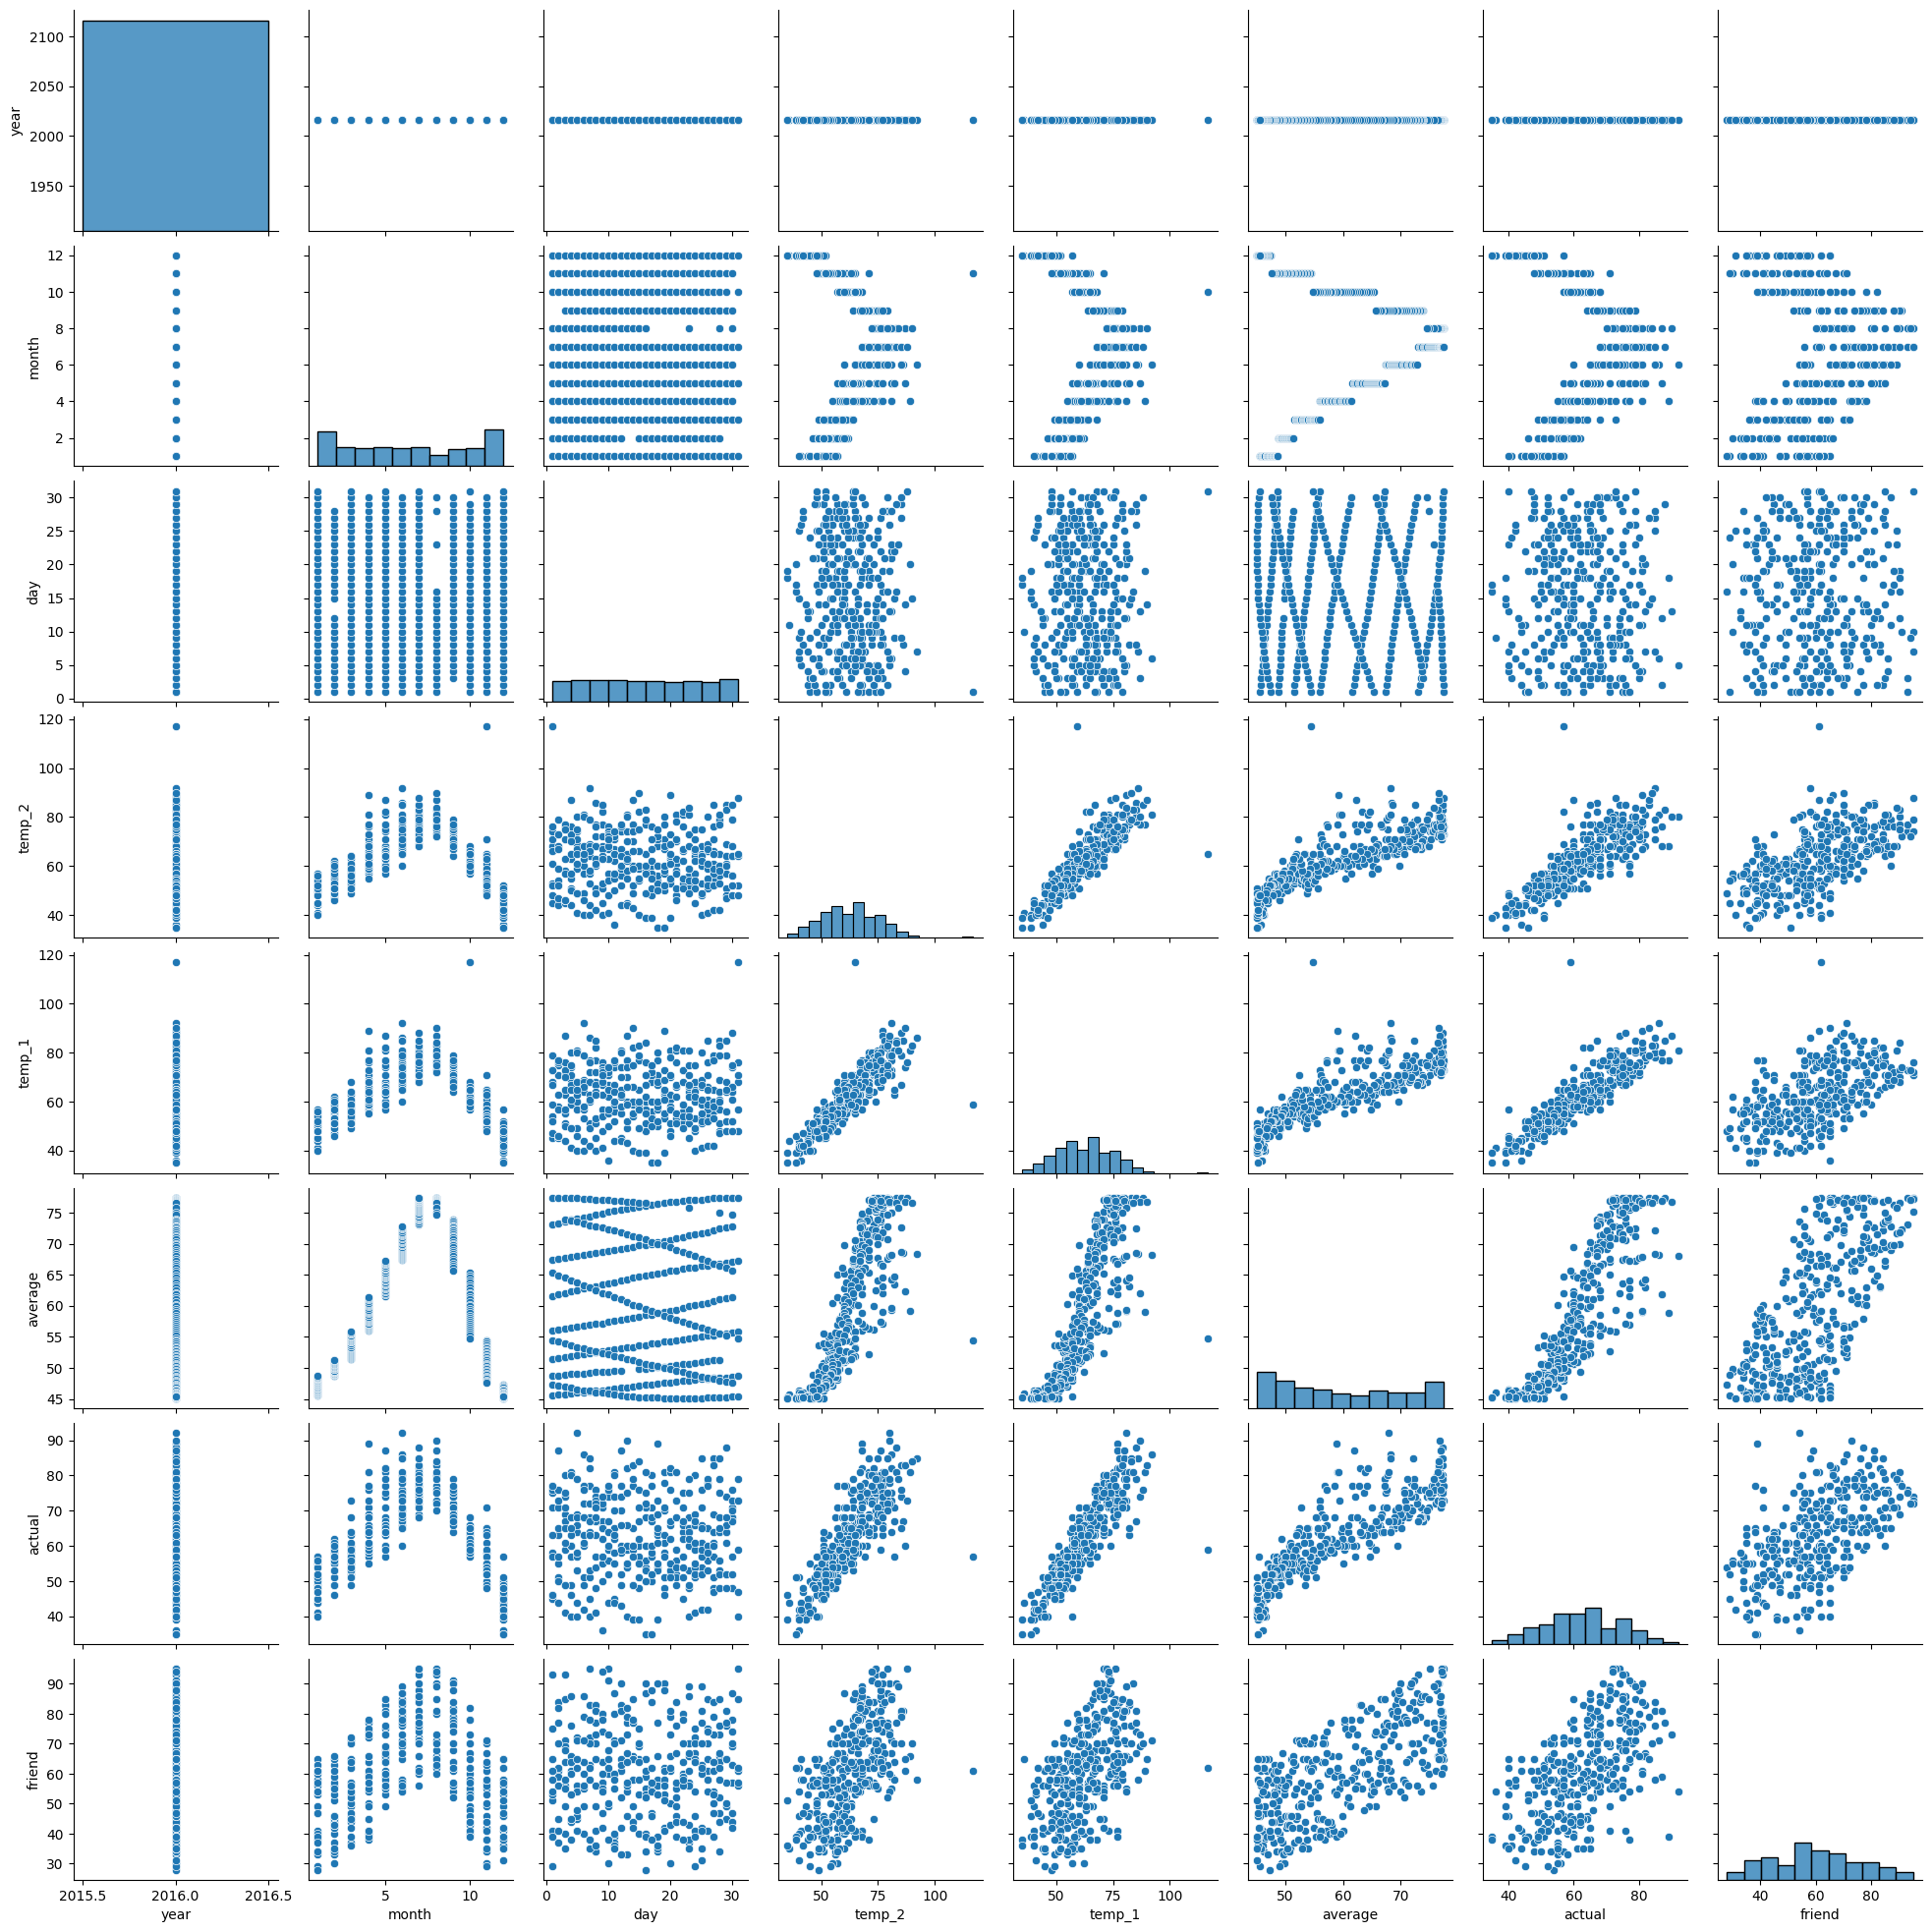

In [5]:
sns.pairplot(df)

<Axes: >

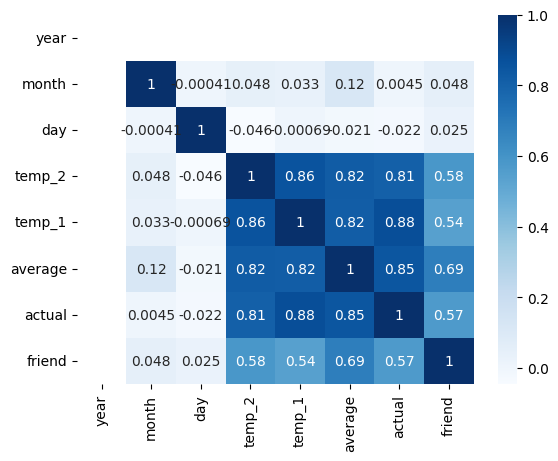

In [6]:
sns.heatmap(df.drop(columns=['week']).corr(), annot=True, cmap='Blues')

### 3. Selecciona variables y divide en train y test

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, mean_squared_log_error, r2_score
from sklearn.tree import plot_tree

In [21]:
def do_tree_regression(X, y, max_depth=2, show_tree=False):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #scaler = StandardScaler()
    #X_train_scal = scaler.fit_transform(X_train)
    #X_test_scal = scaler.transform(X_test)

    tree_reg = DecisionTreeRegressor(random_state=42, max_depth=max_depth)
    tree_reg.fit(X_train, y_train)

    test_predictions = tree_reg.predict(X_test)
    train_predictions = tree_reg.predict(X_train)
    
    print(f'Feature importances:{tree_reg.feature_importances_}')
    print()
    print(f"R2_train: {r2_score(y_train, train_predictions)}")
    print(f"R2_test: {r2_score(y_test, test_predictions)}")
    print()
    print(f'MAE_train: {mean_absolute_error(y_train, train_predictions)}')
    print(f'MAE_test: {mean_absolute_error(y_test, test_predictions)}')
    print()
    print(f'MAPE_train: {mean_absolute_percentage_error(y_train, train_predictions)}')
    print(f'MAPE_test: {mean_absolute_percentage_error(y_test, test_predictions)}')
    print()
    print(f'MSE_train: {mean_squared_error(y_train, train_predictions)}')
    print(f'MSE_test: {mean_squared_error(y_test, test_predictions)}')
    print()
    print(f'RMSE_train: {np.sqrt(mean_squared_error(y_train, train_predictions))}')
    print(f'RMSE_test: {np.sqrt(mean_squared_error(y_test, test_predictions))}')

    if show_tree:
        plt.figure(figsize=(12, 8))
        plot_tree(tree_reg, filled=True)
        plt.show()

### 4. Entrena el modelo


In [9]:
do_tree_regression(df[['month','temp_1']], df['actual'])

Feature importances:[0. 1.]

R2_train: 0.7857803648764965
R2_test: 0.7054063291551216

MAE_train: 4.280441585962386
MAE_test: 5.149219205896223

MAPE_train: 0.07020451919121924
MAPE_test: 0.08334851356554172

MSE_train: 30.24031795211808
MSE_test: 37.473517354614856

RMSE_train: 5.499119743387852
RMSE_test: 6.121561676126024


In [15]:
do_tree_regression(df[['temp_1']], df['actual'])

Feature importances:[1.]

R2_train: 0.7857803648764965
R2_test: 0.7054063291551216

MAE_train: 4.280441585962386
MAE_test: 5.149219205896223

MAPE_train: 0.07020451919121924
MAPE_test: 0.08334851356554172

MSE_train: 30.24031795211808
MSE_test: 37.473517354614856

RMSE_train: 5.499119743387852
RMSE_test: 6.121561676126024


### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

**Observaciones**

- El modelo tiene las mismas métricas entrenandolo solo con la variable ```temp_1```. Se  puede ver que da toda la importancia a esa variable aunque se incluya la variable ```month```.

### 6. Representa el árbol de decisión

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [18]:
do_tree_regression( df[['month','temp_2','temp_1']], df['actual'], max_depth=3)

Feature importances:[0. 0. 1.]

R2_train: 0.8368862113357995
R2_test: 0.7715756282597319

MAE_train: 3.7330268256591905
MAE_test: 4.31567532942782

MAPE_train: 0.061019584755824
MAPE_test: 0.0690401655416445

MSE_train: 23.025960382838985
MSE_test: 29.056512429736554

RMSE_train: 4.798537317020571
RMSE_test: 5.390409300761544


In [12]:
do_tree_regression( df[['temp_1']], df['actual'], max_depth=3)

Feature importances:[1.]

R2_train: 0.8368862113357995
R2_test: 0.7715756282597319

MAE_train: 3.7330268256591905
MAE_test: 4.31567532942782

MAPE_train: 0.061019584755824
MAPE_test: 0.0690401655416445

MSE_train: 23.025960382838985
MSE_test: 29.056512429736554

RMSE_train: 4.798537317020571
RMSE_test: 5.390409300761544


**Observaciones**

- El modelo con profundidad 3 tambien tiene las mismas métricas entrenandolo solo con la variable ```temp_1```. Se  puede ver que da toda la importancia a esa variable aunque se incluya la variable ```month```.

### 8. Vuelve a evaluar tu modelo

### 9. Vuelve a representar su árbol

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [14]:
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10]
}
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring=scoring,
    refit='rmse',
    cv=5
)

grid_search.fit(X, y)
grid_search.best_score_
best_model = grid_search.best_estimator_

df_results = pd.DataFrame(grid_search.cv_results_)

df_results[['param_max_depth','mean_test_rmse','mean_test_mae','mean_test_mape','mean_test_r2']]

NameError: name 'X' is not defined

### 11. Obten el `feature_importances` de cada variable en el último modelo

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [23]:
df['above_59'] = (df['actual'] > 59).astype(int)

In [24]:
df['above_59'].value_counts(normalize=True)

above_59
1    0.586207
0    0.413793
Name: proportion, dtype: float64

Parece que hay un balance razonable para poder clasificar

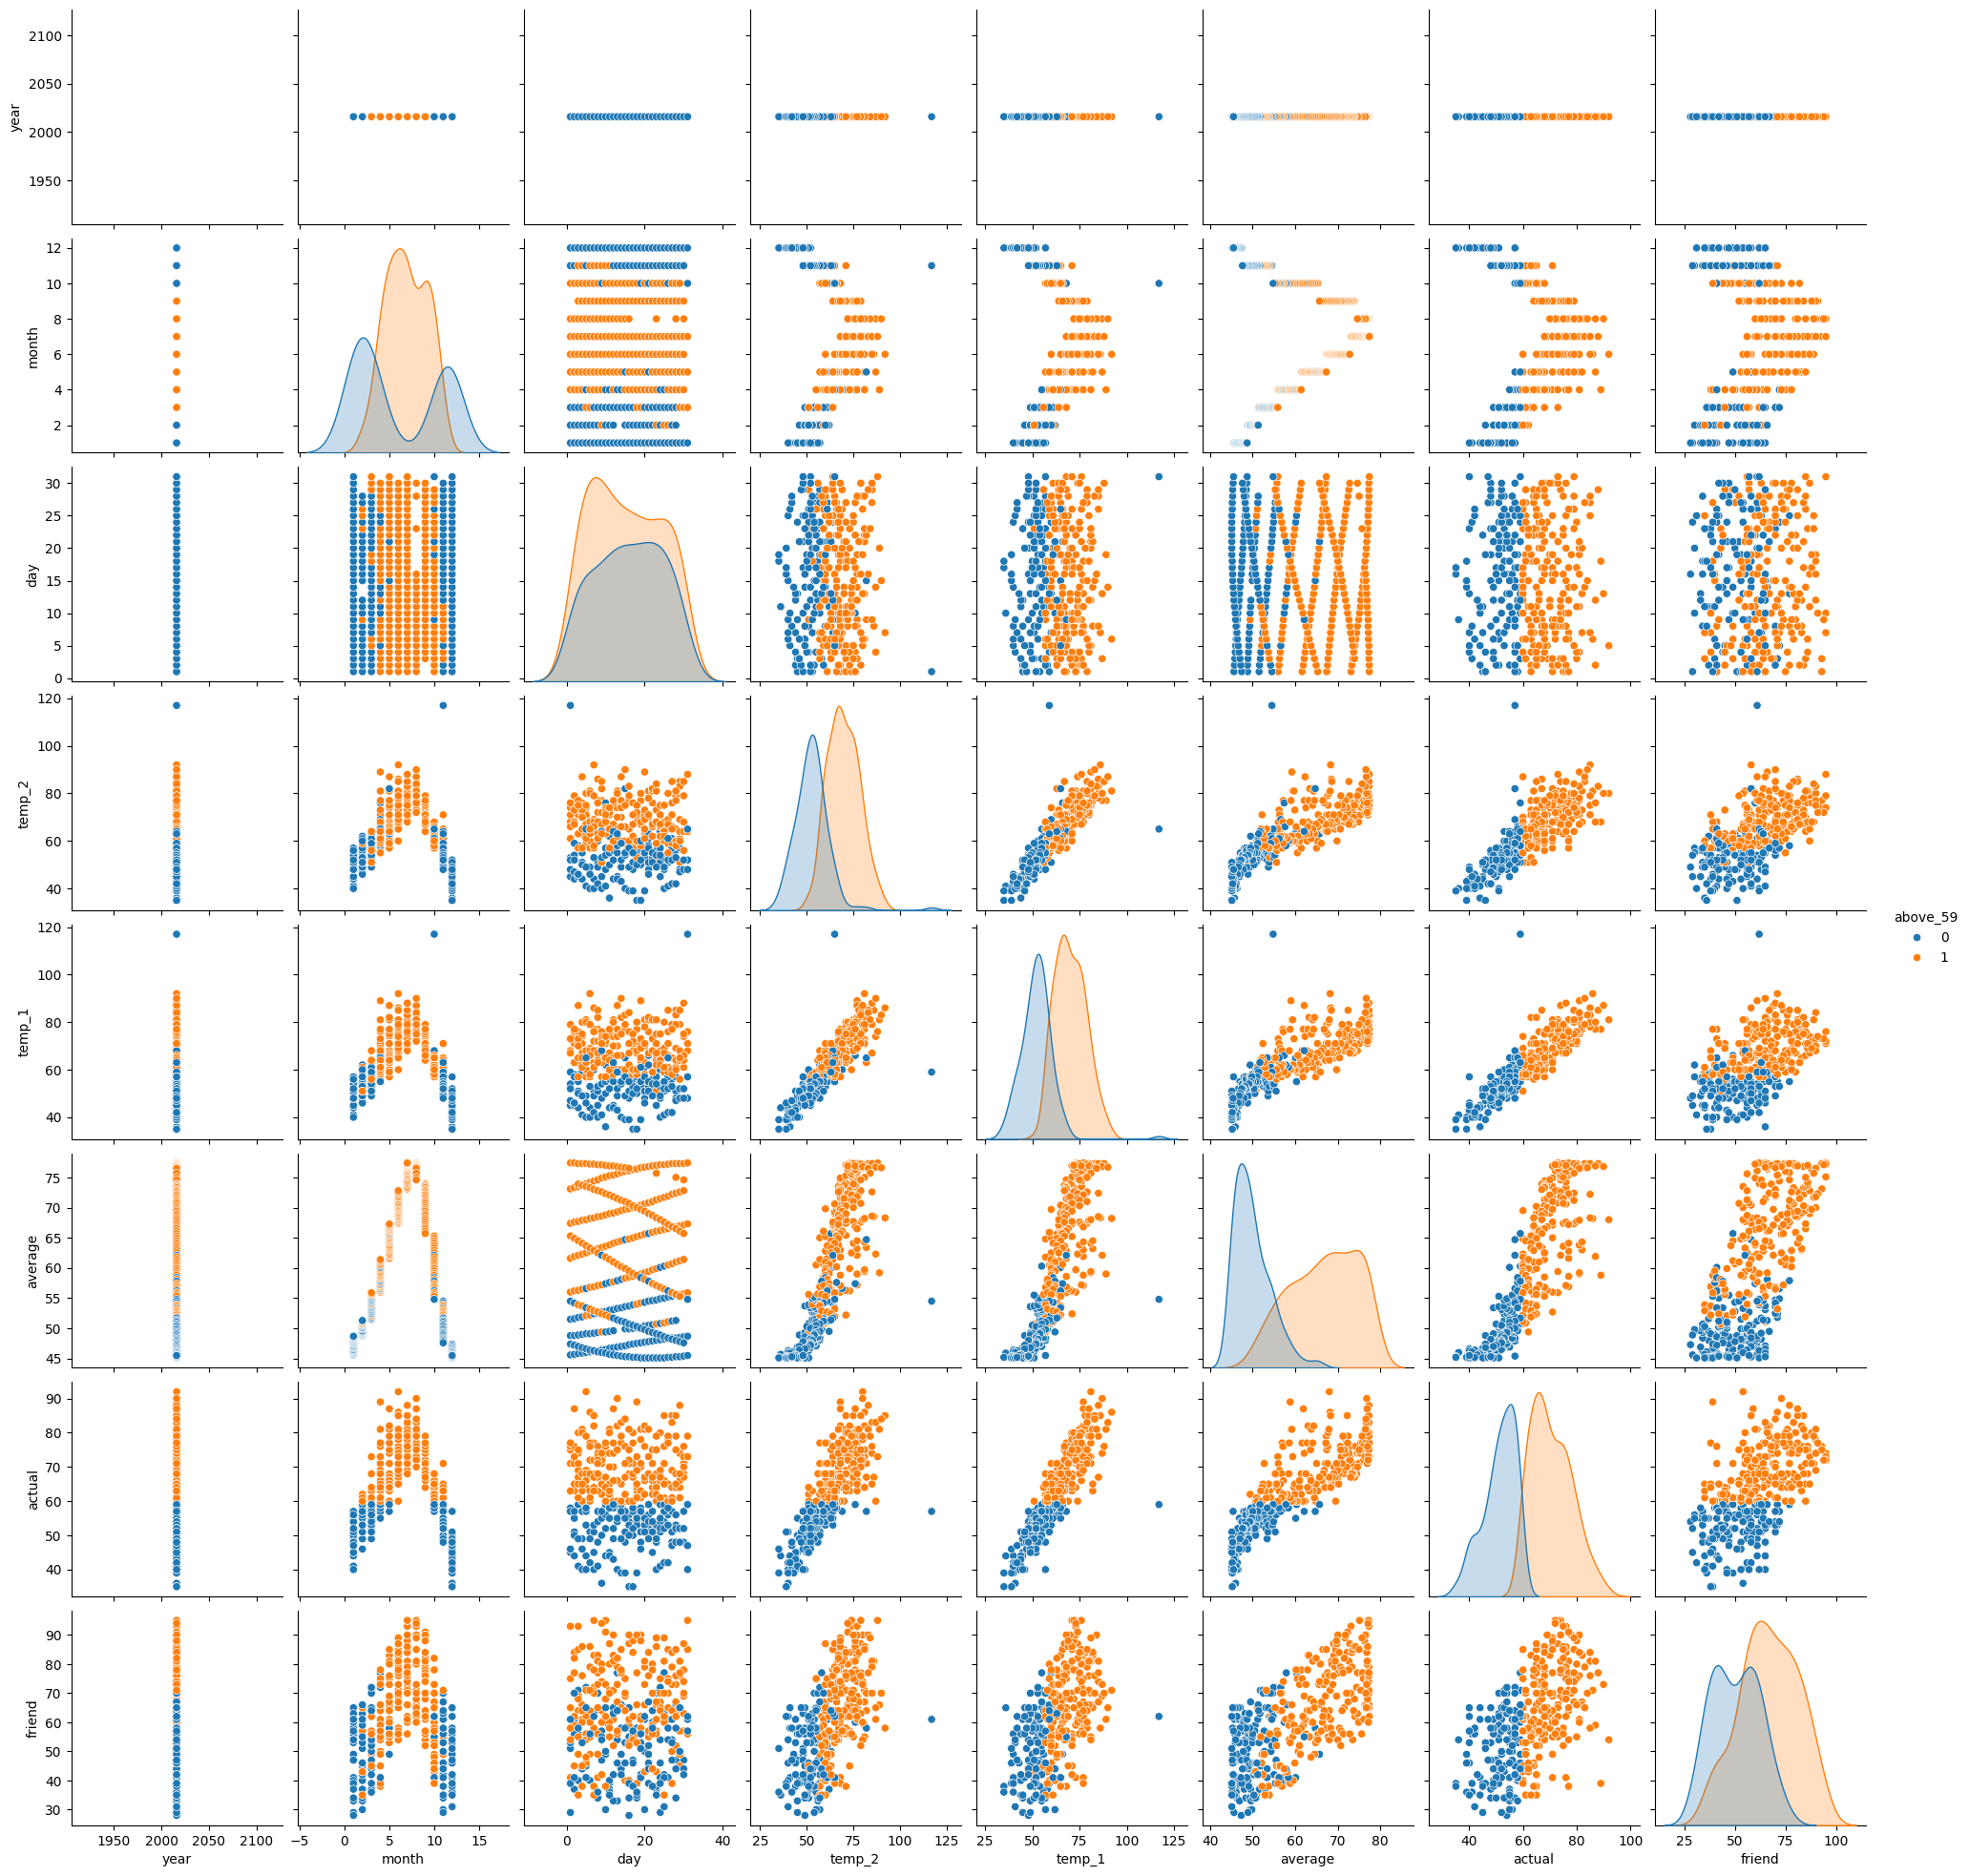

In [25]:
sns.pairplot(df, hue='above_59')

**Observaciones**

- Variables como ```average```, ```temp_1``` y ```month``` tienen buena pinta para usarlas como clasificadoras ya que se ve una clara separación en las temperaturas mayores y menores a 59. 

In [26]:
X = df[['average','temp_1','temp_2','month']].to_numpy()
y = df['above_59'].to_numpy()

In [27]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=109)

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10]
}
scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=109),
    param_grid=param_grid,
    scoring=scoring,
    refit='recall',
    cv=5
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

In [28]:
predictions = best_model.predict(X_test)
pred_proba = best_model.predict_proba(X_test)

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

<Axes: >

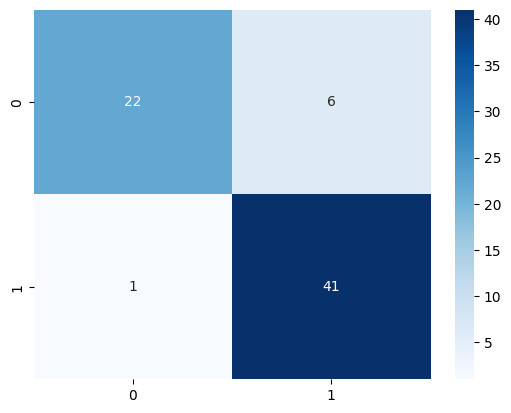

In [30]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, cmap='Blues')

In [31]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.79      0.86        28
           1       0.87      0.98      0.92        42

    accuracy                           0.90        70
   macro avg       0.91      0.88      0.89        70
weighted avg       0.91      0.90      0.90        70



In [32]:
pd.DataFrame(pred_proba)[1].value_counts()

1
0.948718    43
0.054545    23
0.727273     4
Name: count, dtype: int64

In [33]:
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, pred_proba[:,1])

In [34]:
pd.DataFrame({"prec":prec[1:], "rec":rec[1:], "threshold":thresholds})

,prec,rec,threshold
0,0.872340,0.976190,0.054545
1,0.906977,0.928571,0.727273
2,1.000000,0.000000,0.948718


In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

In [36]:
roc_auc_score(y_test, predictions)

0.8809523809523809

In [37]:
fpr, tpr, threshold = roc_curve(y_test, pred_proba[:,1])

In [38]:
pd.DataFrame({"tpr":tpr, "fpr":fpr, "threshold":threshold})

,tpr,fpr,threshold
0,0.000000,0.000000,inf
1,0.928571,0.142857,0.948718
2,0.976190,0.214286,0.727273
3,1.000000,1.000000,0.054545


Text(0.5, 1.0, 'ROC Curve')

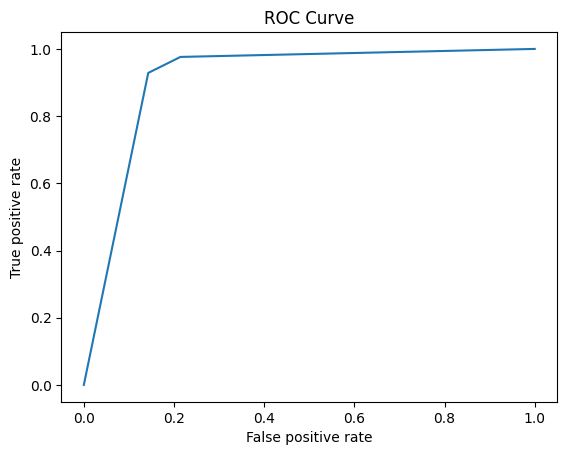

In [39]:
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve")